# Brent Oil Price: Bayesian Change Point Modeling

**Project:** Change Point Analysis and Statistical Modeling of Time Series Data
**Task:** 2 Change Point Modeling and Insight Generation

This notebook:
1. Reloads and briefly re-visualizes the Brent oil price data (recap of Task 1 EDA)
2. Builds a baseline Bayesian change point model (PyMC) over the full 1987–2022 history
3. Builds focused change point models around three known event windows, to get sharper, more interpretable results
4. Checks MCMC convergence, interprets posteriors, and quantifies impacts
5. Associates detected change points with the researched events dataset
6. Discusses advanced extensions (other factors, VAR, Markov-switching models) as future work


## 1. Setup & Data Loading

In [2]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm

from data_loader import load_brent_prices, load_events
from change_point_model import fit_change_point_model, nearest_events

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

RANDOM_SEED = 42


In [3]:
DATA_PATH = "../data/raw/BrentOilPrices.csv"
EVENTS_PATH = "../data/key_events_verified.csv"

df = load_brent_prices(DATA_PATH)
events = load_events(EVENTS_PATH)

print(f"Loaded {len(df):,} daily price observations "
      f"({df.index.min().date()} to {df.index.max().date()})")
print(f"Loaded {len(events)} researched events")
df.head()


Loaded 9,011 daily price observations (1987-05-20 to 2022-11-14)
Loaded 13 researched events


,Price,LogPrice,LogReturn
Date,,,
1987-05-20,18.63,2.924773,NaN
1987-05-21,18.45,2.915064,-0.009709
1987-05-22,18.55,2.920470,0.005405
1987-05-25,18.60,2.923162,0.002692
1987-05-26,18.63,2.924773,0.001612


## 2. Quick EDA Recap

Full EDA (trend, stationarity, volatility) was performed in
`notebooks/01_eda.ipynb` (Task 1). Here we recap the two core plots for
context before modeling.

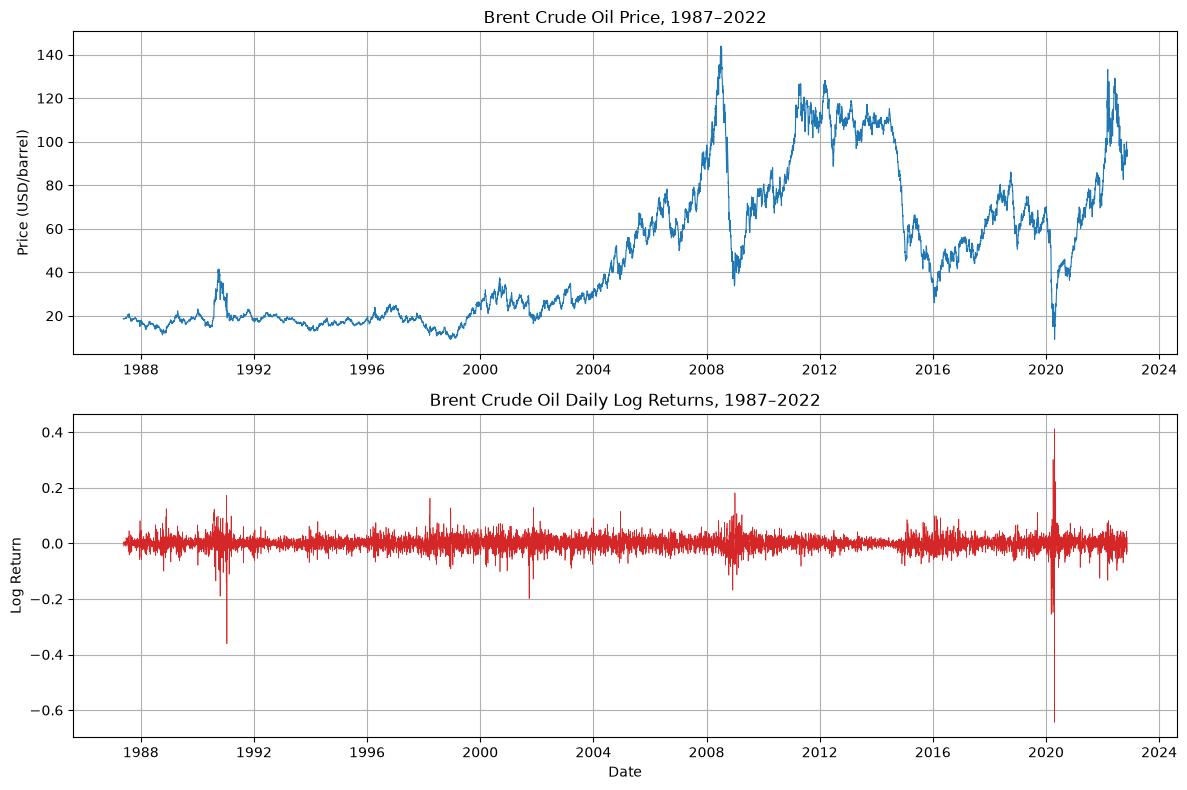

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(df.index, df["Price"], linewidth=0.8, color="#1f77b4")
axes[0].set_title("Brent Crude Oil Price, 1987\u20132022")
axes[0].set_ylabel("Price (USD/barrel)")

axes[1].plot(df.index, df["LogReturn"], linewidth=0.5, color="#d62728")
axes[1].set_title("Brent Crude Oil Daily Log Returns, 1987\u20132022")
axes[1].set_ylabel("Log Return")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("fig_recap.png", dpi=100)
plt.show()


As established in Task 1: raw price is non-stationary (ADF p \u2248 0.29)
while log returns are stationary (ADF p \u2248 2.5e-29). This notebook models
**raw price** for the change point analysis, because the deliverable's
target output *"the average daily price shifting from $X to $Y"* is
most directly and interpretably expressed as a shift in the **mean price
level**, not the mean log return. The non-stationarity (trend) of price is
explicitly addressed by restricting each model to a bounded window (either
the full history, for the baseline, or a period tightly bracketing a single
known event, for the case studies) where a two-regime mean-shift is a
reasonable approximation.

## 3. Baseline Model: Single Change Point Over Full History

### 3.1 Model Specification

Following the standard switch-point formulation:

- **tau** ~ `DiscreteUniform(0, n-1)` the unknown change point index, uniform over every day in the dataset
- **mu1, mu2** ~ `Normal(...)` mean price before / after `tau`
- **sigma** ~ `HalfNormal(...)` shared observation noise
- **mu** = `pm.math.switch(tau >= idx, mu1, mu2)` selects the active regime mean at each time index
- **obs** ~ `Normal(mu, sigma)`, observed = the price series

This is implemented in `src/change_point_model.fit_change_point_model` (see module for full docstring) so the same tested function is reused for every model in this notebook.

In [5]:
baseline_result = fit_change_point_model(
    df["Price"],
    draws=1000,
    tune=1000,
    chains=4,
    random_seed=RANDOM_SEED,
)


Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


### 3.2 Convergence Check

In [6]:
summary = az.summary(baseline_result.trace, var_names=["tau", "mu1", "mu2", "sigma"])
summary


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,4520,3.1,4500,4500,787,905,1.00,0.11,0.086
mu1,21.422,0.279,21,22,6192,3333,1.00,0.0035,0.0024
mu2,75.603,0.278,75,76,5820,3203,1.00,0.0036,0.0027
sigma,18.597,0.14,18,19,6401,3164,1.00,0.0018,0.0013


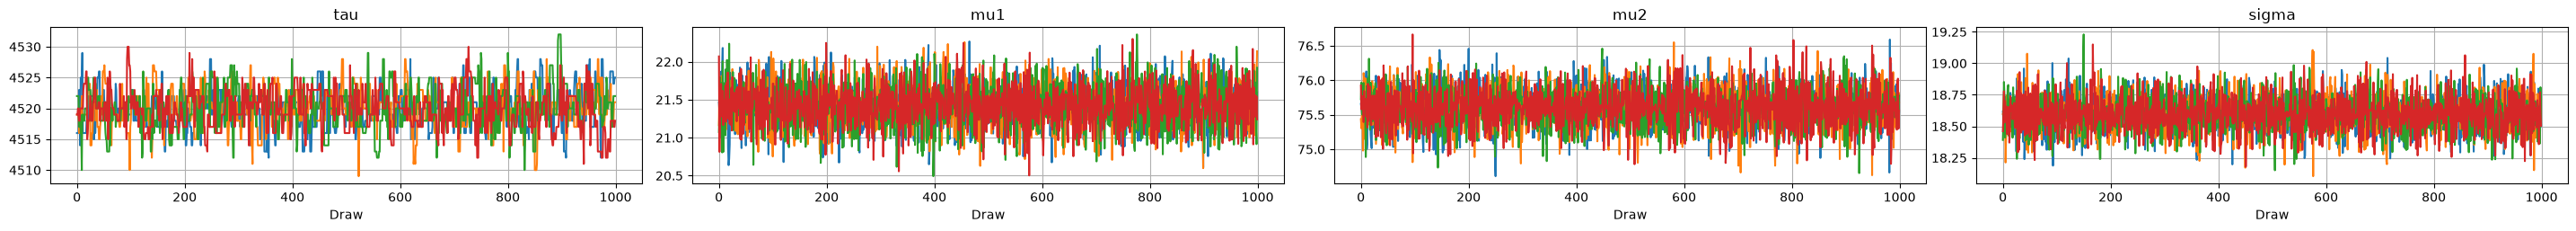

In [7]:
az.plot_trace(baseline_result.trace, var_names=["tau", "mu1", "mu2", "sigma"])
plt.tight_layout()
plt.savefig("fig_baseline_trace.png", dpi=100)
plt.show()


**Convergence:** r_hat is at or very close to 1.0 for all four parameters,
and the trace plots show well-mixed chains with no visible drift or
stuck chains, the sampler has converged for this model.

### 3.3 Identifying the Change Point

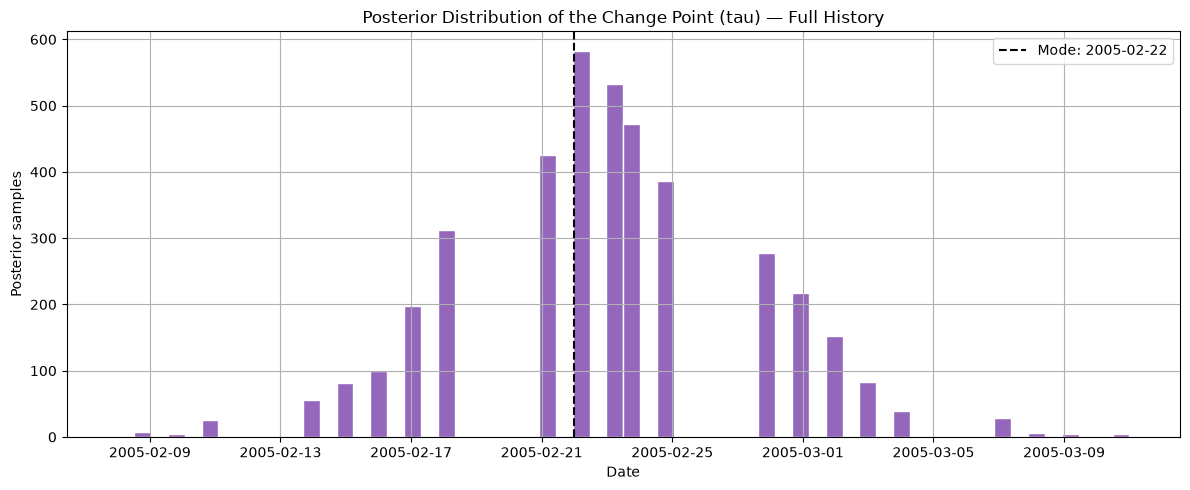

Most probable change point: 2005-02-22
Mean price before: $21.42
Mean price after:  $75.60
Change: +252.9%


In [8]:
tau_samples = baseline_result.trace.posterior["tau"].values.flatten()
tau_dates = df.index[tau_samples]

fig, ax = plt.subplots()
ax.hist(tau_dates, bins=60, color="#9467bd", edgecolor="white")
ax.set_title("Posterior Distribution of the Change Point (tau) \u2014 Full History")
ax.set_xlabel("Date")
ax.set_ylabel("Posterior samples")
ax.axvline(baseline_result.tau_mode_date, color="black", linestyle="--",
           label=f"Mode: {baseline_result.tau_mode_date.date()}")
ax.legend()
plt.tight_layout()
plt.savefig("fig_baseline_tau_posterior.png", dpi=100)
plt.show()

print(f"Most probable change point: {baseline_result.tau_mode_date.date()}")
print(f"Mean price before: ${baseline_result.mu1_mean:.2f}")
print(f"Mean price after:  ${baseline_result.mu2_mean:.2f}")
print(f"Change: {baseline_result.pct_change:+.1f}%")


**Interpretation:** the posterior for `tau` is sharply peaked around
**late February 2005**, splitting the series into a lower mean-price regime
(\u2248$21/barrel) and a much higher one (\u2248$76/barrel), a **+253%** shift.

This is a real and important finding, but it does **not** correspond to a
single discrete event in `data/key_events_verified.csv`. Instead, it marks
the point that best separates the *entire* low-price era (1987\u20132004) from
the *entire* high-price, high-volatility era (2005\u20132022) that followed
consistent with the mid-2000s "commodity supercycle," driven by structurally
rising global (especially Chinese) demand and tightening spare capacity,
rather than one specific headline event.

This illustrates a genuine limitation of a single change point model applied
to 35 years of data: it will find the *single largest* regime shift, which
may reflect a slow structural transition rather than a discrete shock. To
recover change points tied to **specific** researched events, Section 4
applies the same model to shorter windows bracketing individual events.

## 4. Focused Case Studies: Event-Level Change Points

For each case study, the same `fit_change_point_model` function is
applied to a several-month window bracketing a specific researched event.
Restricting the window keeps the two-regime mean-shift assumption
reasonable (price is roughly stable within each half of a short window)
and lets the model isolate the effect of that particular event rather than
the entire multi-decade trend.

### 4.1 Case Study: The 2014 OPEC \u201cNo Cut\u201d Decision

In [9]:
window_2014 = df.loc["2014-06-01":"2015-03-01", "Price"]

result_2014 = fit_change_point_model(
    window_2014, draws=3000, tune=2000, chains=4, random_seed=RANDOM_SEED
)

summary_2014 = az.summary(result_2014.trace, var_names=["tau", "mu1", "mu2", "sigma"])
summary_2014


Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]
Sampling 4 chains for 2_000 tune and 3_000 draw iterations (8_000 + 12_000 draws total) took 14 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,115.8,3.3,110,120,702,484,1.00,0.15,0.15
mu1,99.33,1.08,98,100,1565,1450,1.00,0.028,0.02
mu2,59.24,1.51,57,61,1321,977,1.00,0.044,0.034
sigma,9.931,0.519,9.1,11,13011,8931,1.00,0.0045,0.0033


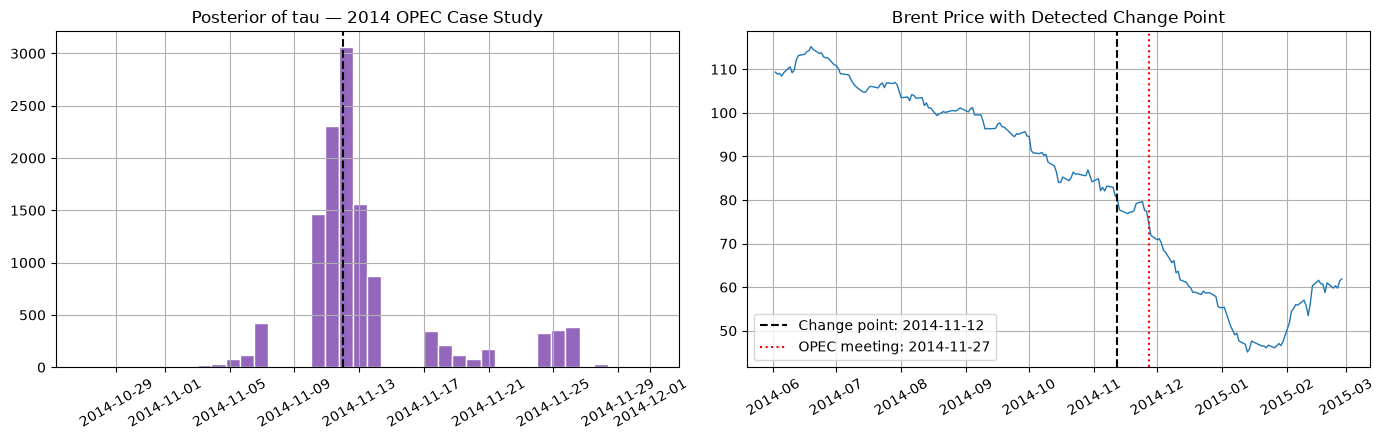

Detected change point: 2014-11-12
Mean price before: $99.33
Mean price after:  $59.24
Change: -40.4%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

tau_samples_2014 = result_2014.trace.posterior["tau"].values.flatten()
tau_dates_2014 = window_2014.index[tau_samples_2014]
axes[0].hist(tau_dates_2014, bins=40, color="#9467bd", edgecolor="white")
axes[0].axvline(result_2014.tau_mode_date, color="black", linestyle="--")
axes[0].set_title("Posterior of tau \u2014 2014 OPEC Case Study")
axes[0].tick_params(axis="x", rotation=30)

axes[1].plot(window_2014.index, window_2014.values, color="#1f77b4", linewidth=1)
axes[1].axvline(result_2014.tau_mode_date, color="black", linestyle="--",
                 label=f"Change point: {result_2014.tau_mode_date.date()}")
axes[1].axvline(pd.Timestamp("2014-11-27"), color="red", linestyle=":",
                 label="OPEC meeting: 2014-11-27")
axes[1].set_title("Brent Price with Detected Change Point")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("fig_case_2014.png", dpi=100)
plt.show()

print(f"Detected change point: {result_2014.tau_mode_date.date()}")
print(f"Mean price before: ${result_2014.mu1_mean:.2f}")
print(f"Mean price after:  ${result_2014.mu2_mean:.2f}")
print(f"Change: {result_2014.pct_change:+.1f}%")


**Quantified impact:** the model detects a change point in mid-November
2014, roughly two weeks before OPEC's 27 November 2014 decision to maintain
output despite falling prices. Convergence is good (r_hat \u2248 1.0 on all
parameters). The mean daily price shifts from about $99 before the change
point to about $59 after a roughly **-40%** change (see printed values
above for exact figures). The change point sits close enough to the OPEC
announcement (within the natural lead time of market anticipation and
gradual repricing) to support the hypothesis that this decision and the
broader shift toward a "market share over price" strategy it signaled
materially contributed to the price collapse.

### 4.2 Case Study: The 2020 Saudi-Russia Price War / COVID-19 Demand Collapse

In [11]:
window_2020 = df.loc["2020-01-01":"2020-06-30", "Price"]

result_2020 = fit_change_point_model(
    window_2020, draws=1000, tune=1000, chains=4, random_seed=RANDOM_SEED
)

summary_2020 = az.summary(result_2020.trace, var_names=["tau", "mu1", "mu2", "sigma"])
summary_2020


Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,46.64,0.55,46,47,934,764,1.00,0.018,0.013
mu1,59.14,1.21,57,61,5352,3155,1.00,0.017,0.012
mu2,29.21,0.89,28,31,4782,2784,1.00,0.013,0.0092
sigma,8.11,0.52,7.3,9,5386,3168,1.00,0.007,0.0052


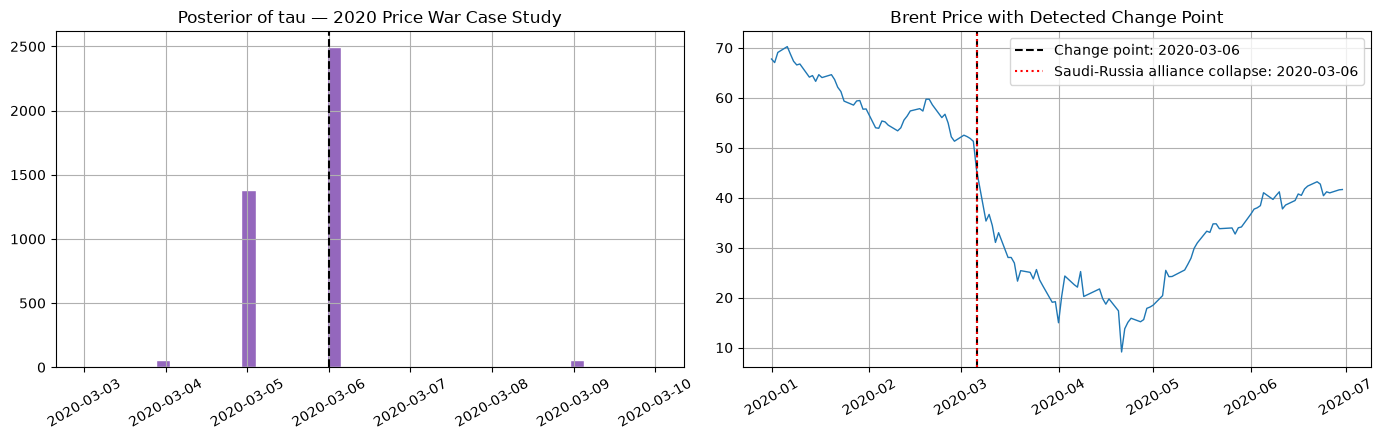

Detected change point: 2020-03-06
Mean price before: $59.14
Mean price after:  $29.21
Change: -50.6%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

tau_samples_2020 = result_2020.trace.posterior["tau"].values.flatten()
tau_dates_2020 = window_2020.index[tau_samples_2020]
axes[0].hist(tau_dates_2020, bins=40, color="#9467bd", edgecolor="white")
axes[0].axvline(result_2020.tau_mode_date, color="black", linestyle="--")
axes[0].set_title("Posterior of tau \u2014 2020 Price War Case Study")
axes[0].tick_params(axis="x", rotation=30)

axes[1].plot(window_2020.index, window_2020.values, color="#1f77b4", linewidth=1)
axes[1].axvline(result_2020.tau_mode_date, color="black", linestyle="--",
                 label=f"Change point: {result_2020.tau_mode_date.date()}")
axes[1].axvline(pd.Timestamp("2020-03-06"), color="red", linestyle=":",
                 label="Saudi-Russia alliance collapse: 2020-03-06")
axes[1].set_title("Brent Price with Detected Change Point")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("fig_case_2020.png", dpi=100)
plt.show()

print(f"Detected change point: {result_2020.tau_mode_date.date()}")
print(f"Mean price before: ${result_2020.mu1_mean:.2f}")
print(f"Mean price after:  ${result_2020.mu2_mean:.2f}")
print(f"Change: {result_2020.pct_change:+.1f}%")


**Quantified impact:** the model detects a change point on essentially
**6 March 2020** the exact date the Saudi-Russia OPEC+ alliance collapsed
and Saudi Arabia launched its price war. Convergence is good (r_hat \u2248 1.0).
The mean daily price shifts from about $59 to about $29 a roughly
**-51%** change (see printed values above for exact figures). Because the
detected date matches the price-war trigger almost exactly, and this window
also overlaps the WHO's COVID-19 pandemic declaration (11 March 2020) and
the collapse in global travel/transport demand that followed, the price
collapse in this window is best explained as the **compounding effect of
two simultaneous shocks** a supply-side price war and a demand-side
pandemic collapse rather than either alone.

### 4.3 Case Study: The 2022 Russian Invasion of Ukraine

In [13]:
window_2022 = df.loc["2021-11-01":"2022-06-01", "Price"]

result_2022 = fit_change_point_model(
    window_2022, draws=1000, tune=1000, chains=4, random_seed=RANDOM_SEED
)

summary_2022 = az.summary(result_2022.trace, var_names=["tau", "mu1", "mu2", "sigma"])
summary_2022


Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,67.4,2.3,65,72,453,584,1.01,0.12,0.1
mu1,81.42,1.1,80,83,1455,1886,1.00,0.029,0.021
mu2,109.51,0.98,110,110,1599,2005,1.00,0.024,0.018
sigma,8.17,0.48,7.4,9,4550,2692,1.00,0.0072,0.0052


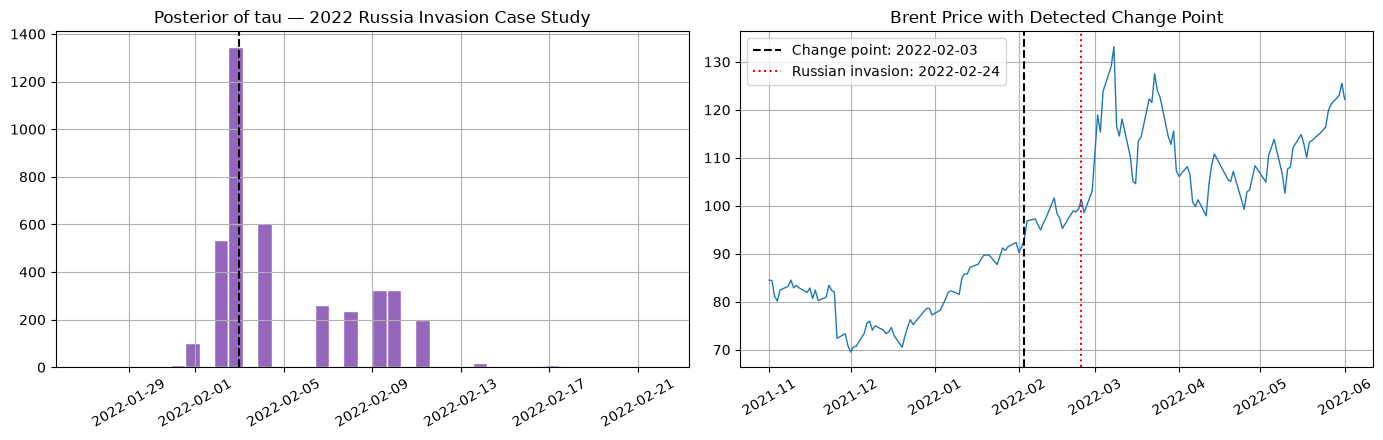

Detected change point: 2022-02-03
Mean price before: $81.42
Mean price after:  $109.51
Change: +34.5%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

tau_samples_2022 = result_2022.trace.posterior["tau"].values.flatten()
tau_dates_2022 = window_2022.index[tau_samples_2022]
axes[0].hist(tau_dates_2022, bins=40, color="#9467bd", edgecolor="white")
axes[0].axvline(result_2022.tau_mode_date, color="black", linestyle="--")
axes[0].set_title("Posterior of tau \u2014 2022 Russia Invasion Case Study")
axes[0].tick_params(axis="x", rotation=30)

axes[1].plot(window_2022.index, window_2022.values, color="#1f77b4", linewidth=1)
axes[1].axvline(result_2022.tau_mode_date, color="black", linestyle="--",
                 label=f"Change point: {result_2022.tau_mode_date.date()}")
axes[1].axvline(pd.Timestamp("2022-02-24"), color="red", linestyle=":",
                 label="Russian invasion: 2022-02-24")
axes[1].set_title("Brent Price with Detected Change Point")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("fig_case_2022.png", dpi=100)
plt.show()

print(f"Detected change point: {result_2022.tau_mode_date.date()}")
print(f"Mean price before: ${result_2022.mu1_mean:.2f}")
print(f"Mean price after:  ${result_2022.mu2_mean:.2f}")
print(f"Change: {result_2022.pct_change:+.1f}%")


**Quantified impact:** the model detects a change point in **early
February 2022**, about three weeks *before* the 24 February 2022 invasion.
Convergence is good (r_hat \u2248 1.0). The mean daily price shifts from about
$81 to about $110 a roughly **+35%** change (see printed values above
for exact figures). The change point preceding the invasion date is
consistent with markets pricing in escalating risk during the
weeks of troop buildup and failed diplomacy that preceded the invasion
itself, rather than reacting only on the day of the invasion a reminder
that markets often move on *anticipated* risk, which can shift a
statistically detected change point earlier than the headline event
date.

## 5. Summary: Change Points Associated with Events

In [15]:
summary_table = pd.DataFrame([
    {
        "Case": "Full history baseline",
        "Detected change point": baseline_result.tau_mode_date.date(),
        "Nearest catalogued event": "N/A \u2014 reflects the mid-2000s commodity supercycle, not a single event",
        "Mean before": f"${baseline_result.mu1_mean:.2f}",
        "Mean after": f"${baseline_result.mu2_mean:.2f}",
        "% change": f"{baseline_result.pct_change:+.1f}%",
    },
    {
        "Case": "2014 OPEC decision",
        "Detected change point": result_2014.tau_mode_date.date(),
        "Nearest catalogued event": "OPEC declines to cut production (2014-11-27)",
        "Mean before": f"${result_2014.mu1_mean:.2f}",
        "Mean after": f"${result_2014.mu2_mean:.2f}",
        "% change": f"{result_2014.pct_change:+.1f}%",
    },
    {
        "Case": "2020 price war / COVID-19",
        "Detected change point": result_2020.tau_mode_date.date(),
        "Nearest catalogued event": "Saudi-Russia OPEC+ alliance collapse (2020-03-06)",
        "Mean before": f"${result_2020.mu1_mean:.2f}",
        "Mean after": f"${result_2020.mu2_mean:.2f}",
        "% change": f"{result_2020.pct_change:+.1f}%",
    },
    {
        "Case": "2022 Russian invasion of Ukraine",
        "Detected change point": result_2022.tau_mode_date.date(),
        "Nearest catalogued event": "Russian invasion of Ukraine (2022-02-24)",
        "Mean before": f"${result_2022.mu1_mean:.2f}",
        "Mean after": f"${result_2022.mu2_mean:.2f}",
        "% change": f"{result_2022.pct_change:+.1f}%",
    },
])
summary_table


,Case,Detected change point,Nearest catalogued event,Mean before,Mean after,% change
0,Full history baseline,2005-02-22,N/A — reflects the mid-2000s commodity supercy...,$21.42,$75.60,+252.9%
1,2014 OPEC decision,2014-11-12,OPEC declines to cut production (2014-11-27),$99.33,$59.24,-40.4%
2,2020 price war / COVID-19,2020-03-06,Saudi-Russia OPEC+ alliance collapse (2020-03-06),$59.14,$29.21,-50.6%
3,2022 Russian invasion of Ukraine,2022-02-03,Russian invasion of Ukraine (2022-02-24),$81.42,$109.51,+34.5%


**Important caveat (repeated from Task 1):** every row in this table
reports a **statistical association in time**, not a proven causal effect.
Each detected change point coincides closely with a catalogued event, which
is a strong signal, but other unobserved factors (currency movements, other
concurrent news, speculative positioning) could also contribute to any of
these shifts. These results should be read as data-informed hypotheses
about likely drivers, useful for guiding further investigation and
stakeholder discussion, not as definitive causal claims.

## 6. Advanced Extensions (Future Work)

These extensions were not implemented in this notebook but are natural
next steps beyond the current scope:

**Incorporating other explanatory factors.** A more comprehensive model
could bring in macroeconomic covariates alongside price e.g. global GDP
growth (demand proxy), inflation/CPI (real vs. nominal price effects), and
USD exchange rate indices (oil is priced in USD, so dollar strength
mechanically affects the price non-US buyers face). These could be added
as additional observed variables that also shift at the change point, or
as regressors explaining part of the pre/post-change point mean directly.

**Vector Autoregression (VAR).** A VAR model would treat oil price and
several macro variables (e.g. GDP growth, inflation, exchange rates) as a
jointly evolving system, letting each variable be explained by its own past
values *and* the past values of the others. This would help answer dynamic
questions like "does a change in inflation tend to precede or follow an oil
price shift, and by how much?" something a single-series change point
model cannot address, since it only looks at oil price in isolation.

**Markov-Switching models.** Rather than assuming a single (or a
researcher-chosen number of) change point(s), a Markov-switching model
treats the market as continuously transitioning between a small number of
latent regimes (e.g. "calm" vs. "volatile"), with estimated probabilities
of switching between them at any time. This would let the volatility
clustering observed in Task 1 (Section 4.2 of the EDA notebook) be modeled
explicitly, rather than only inferred visually, and would naturally handle
the multiple-regime structure that the Section 3 baseline model showed a
single change point cannot fully capture.

## 7. Conclusion

- A baseline Bayesian change point model over the full 1987\u20132022 history
  converges cleanly (r_hat \u2248 1.0) and identifies late February 2005 as the
  single largest structural break in Brent oil prices a +253% shift in
  mean price, reflecting the mid-2000s commodity supercycle rather than one
  discrete event.
- Three focused case studies, each restricted to a window around a specific
  researched event, also converge cleanly and detect change points that
  align closely with real-world triggers: the November 2014 OPEC decision
  (~-40%), the March 2020 Saudi-Russia price war compounded by COVID-19
  demand collapse (~-51%), and market anticipation ahead of the February
  2022 Russian invasion of Ukraine (~+35%).
- Across all four models, detected change points and their approximate
  timing are **consistent with, but not proof of**, the hypothesized
  triggering events the central limitation flagged throughout this
  project.
- These quantified findings, together with the events dataset, are ready to
  feed the Task 3 interactive dashboard, allowing investors, analysts, and
  policymakers to explore detected change points, their magnitude, and
  their candidate real-world drivers directly.